# Lasso Logistic Regression xG Model

Trains and evaluates an L1-penalised (Lasso) logistic regression expected-goals model on StatsBomb open data.

The key property of Lasso is **sparsity**: as regularisation increases, coefficients are driven to exactly zero, performing automatic feature selection. This makes Lasso useful for understanding which features are truly necessary for xG prediction versus which are redundant.

Serie A 2015/16 is held out entirely as a test set — never used to fit the preprocessor,
tune `C`, or run cross-validation — so the final evaluation reflects genuine
generalisation to an unseen competition, not just CV performance on the same folds used
to select `C`.

**Pipeline summary:**
1. Load data, engineer features, and split off Serie A 2015/16 as a held-out test set
2. Preprocess — standardise numerics, encode categoricals, impute (fit on training shots only)
3. Tune regularisation strength `C` with Optuna (5-fold CV on training shots, log-loss)
4. Final evaluation — training-CV metrics vs true held-out test metrics (AUC, log-loss, Brier score)
5. Calibration curve (held-out test)
6. Regularisation path — how sparsity evolves across `C` values (training shots)
7. Surviving feature coefficients at the best `C` (training shots)
8. Baseline comparison (Ridge vs Lasso vs distance-only, held-out test)
9. Save model to `outputs/`
10. Results summary

In [17]:
import sys, warnings, os
warnings.filterwarnings('ignore')
sys.path.insert(0, '..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import joblib
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.metrics import (
    roc_auc_score, log_loss, brier_score_loss,
    RocCurveDisplay, PrecisionRecallDisplay,
)
from sklearn.calibration import calibration_curve
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from statsbombpy import sb

from src.features import create_xg_features

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.dpi'] = 120
os.makedirs('../outputs', exist_ok=True)

## 1. Data Loading and Feature Engineering

In [18]:
COMPETITIONS = [
    {'competition_id': 11, 'season_id': 27,  'label': 'La Liga 2015/16'},
    {'competition_id': 16, 'season_id': 4,   'label': 'Champions League 2018/19'},
    {'competition_id': 2,  'season_id': 27,  'label': 'Premier League 2015/16'},
    {'competition_id': 43, 'season_id': 106, 'label': 'World Cup 2022'},
    {'competition_id': 12, 'season_id': 27,  'label': 'Serie A 2015/16'},
]

# Held out entirely from preprocessing fits, hyperparameter tuning, and CV —
# used only as a final, untouched test set to check generalisation to an
# unseen competition, rather than relying solely on CV metrics that share
# folds with the hyperparameter search.
HOLDOUT_LABEL = 'Serie A 2015/16'

def load_competition(competition_id, season_id):
    matches = sb.matches(competition_id=competition_id, season_id=season_id)
    events = pd.concat(
        [sb.events(match_id=mid).assign(match_id=mid) for mid in matches['match_id']],
        ignore_index=True,
    )
    return matches['match_id'].tolist(), events

all_events = []
match_id_to_label = {}
for comp in COMPETITIONS:
    print(f"Loading {comp['label']}…")
    match_ids, events = load_competition(comp['competition_id'], comp['season_id'])
    for mid in match_ids:
        match_id_to_label[mid] = comp['label']
    all_events.append(events)

events_df = pd.concat(all_events, ignore_index=True)
xg_df = create_xg_features(events_df)

shots = xg_df[xg_df['is_penalty'] == 0].copy().reset_index(drop=True)
shots['competition_label'] = shots['match_id'].map(match_id_to_label)

is_holdout = shots['competition_label'] == HOLDOUT_LABEL
shots_train = shots[~is_holdout].reset_index(drop=True)
shots_test = shots[is_holdout].reset_index(drop=True)

train_labels = ', '.join(c['label'] for c in COMPETITIONS if c['label'] != HOLDOUT_LABEL)
print(f"\nTotal shots (excl. penalties): {len(shots):,}")
print(f"  Train ({train_labels}): {len(shots_train):,} shots, "
      f"{shots_train['is_goal'].mean():.1%} goal rate")
print(f"  Held-out test ({HOLDOUT_LABEL}): {len(shots_test):,} shots, "
      f"{shots_test['is_goal'].mean():.1%} goal rate")

Loading La Liga 2015/16…
Loading Champions League 2018/19…
Loading Premier League 2015/16…
Loading World Cup 2022…
Loading Serie A 2015/16…

Total shots (excl. penalties): 30,224
  Train (La Liga 2015/16, Champions League 2018/19, Premier League 2015/16, World Cup 2022): 20,347 shots, 9.9% goal rate
  Held-out test (Serie A 2015/16): 9,877 shots, 8.7% goal rate


## 2. Preprocessing

Identical to the Ridge notebook — Lasso is also scale-sensitive, so `StandardScaler` is required. The `saga` solver is used instead of `lbfgs` because `lbfgs` does not support L1 regularisation.

In [19]:
CATEGORICAL_FEATURES = ['shot_body_part', 'shot_technique', 'previous_event_type']

NUMERIC_FEATURES = [
    'distance_to_goal', 'shot_angle', 'centrality',
    'in_penalty_area', 'in_six_yard_box',
    'shot_first_time', 'shot_under_pressure',
    'num_defenders_in_frame', 'num_teammates_in_frame',
    'distance_to_nearest_defender', 'num_defenders_between_shot_and_goal',
    'goalkeeper_distance_to_goal', 'goalkeeper_distance_to_shooter',
    'previous_event_was_pass', 'previous_event_was_carry',
    'previous_event_same_team', 'previous_event_distance',
    'is_late_game', 'is_extra_time',
]

TARGET = 'is_goal'

preprocessor = ColumnTransformer([
    ('num', Pipeline([
        ('impute', SimpleImputer(strategy='median')),
        ('scale',  StandardScaler()),
    ]), NUMERIC_FEATURES),
    ('cat', Pipeline([
        ('impute', SimpleImputer(strategy='constant', fill_value='Unknown')),
        ('ohe',    OneHotEncoder(handle_unknown='ignore', sparse_output=False)),
    ]), CATEGORICAL_FEATURES),
], remainder='drop')

# Only training-competition shots are used to fit the preprocessor, tune C,
# and run CV. The held-out test set is transformed later with the fitted
# preprocessor but never used to fit anything.
X = shots_train[NUMERIC_FEATURES + CATEGORICAL_FEATURES]
y = shots_train[TARGET].values

X_test = shots_test[NUMERIC_FEATURES + CATEGORICAL_FEATURES]
y_test = shots_test[TARGET].values

X_transformed = preprocessor.fit_transform(X)
ohe_feature_names = (
    preprocessor.named_transformers_['cat']['ohe']
    .get_feature_names_out(CATEGORICAL_FEATURES)
    .tolist()
)
ALL_FEATURE_NAMES = NUMERIC_FEATURES + ohe_feature_names
print(f"Feature matrix (train): {X_transformed.shape[0]:,} shots × {X_transformed.shape[1]} features")

Feature matrix (train): 20,347 shots × 54 features


## 3. Hyperparameter Tuning (Optuna)

In [37]:
CV = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

def objective(trial):
    C = trial.suggest_float('C', 1e-4, 1e3, log=True)
    model = Pipeline([
        ('pre', preprocessor),
        ('clf', LogisticRegression(
            penalty='l1', C=C, solver='saga',
            max_iter=2000, random_state=42,
        )),
    ])
    fold_losses = []
    for train_idx, val_idx in CV.split(X, y):
        model.fit(X.iloc[train_idx], y[train_idx])
        proba = model.predict_proba(X.iloc[val_idx])[:, 1]
        fold_losses.append(log_loss(y[val_idx], proba))
    return np.mean(fold_losses)

study = optuna.create_study(direction='minimize', sampler=optuna.samplers.TPESampler(seed=42))
study.optimize(objective, n_trials=40, show_progress_bar=True)

best_C = study.best_params['C']
print(f"\nBest log-loss: {study.best_value:.4f}\n")

# Search-space bounds are read back from Optuna's own trial distributions
# (not re-declared) so this table can't drift out of sync with objective().
tuning_summary = pd.DataFrame([
    {'Parameter': name, 'Min': dist.low, 'Max': dist.high, 'Best': study.best_params[name]}
    for name, dist in study.best_trial.distributions.items()
]).set_index('Parameter')
print("Hyperparameter search space vs. selected value:")
print(tuning_summary.to_string())

  0%|          | 0/40 [00:00<?, ?it/s]


Best log-loss: 0.2606

Hyperparameter search space vs. selected value:
              Min     Max      Best
Parameter                          
C          0.0001  1000.0  0.663968


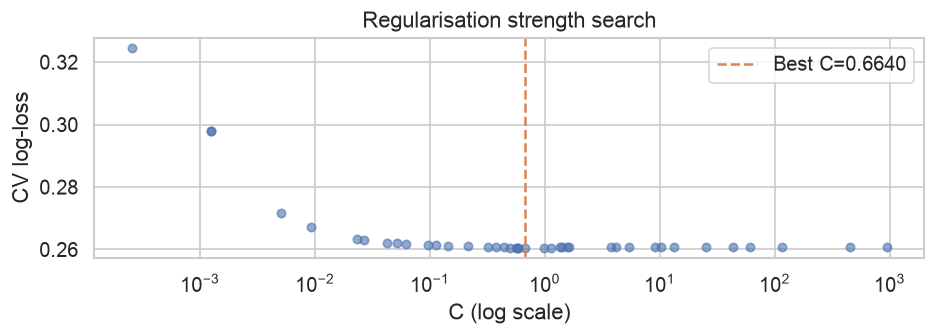

In [21]:
trials_df = study.trials_dataframe().sort_values('params_C')

fig, ax = plt.subplots(figsize=(8, 3))
ax.semilogx(trials_df['params_C'], trials_df['value'], 'o', alpha=0.6, ms=5, color='#4C72B0')
ax.axvline(best_C, color='#DD8452', linewidth=1.5, linestyle='--', label=f'Best C={best_C:.4f}')
ax.set_xlabel('C (log scale)')
ax.set_ylabel('CV log-loss')
ax.set_title('Regularisation strength search')
ax.legend()
plt.tight_layout()
plt.show()

## 4. Final Evaluation — Training CV vs Held-Out Test

The training-CV metrics reuse the same folds used during the `C` search, so they carry
a mild optimistic bias. The held-out test metrics come from Serie A 2015/16, a
competition never touched during tuning or CV, and are the more trustworthy estimate of
real generalisation. All later sections (calibration, model comparison) use the
held-out test predictions.

In [22]:
final_model = Pipeline([
    ('pre', preprocessor),
    ('clf', LogisticRegression(
        penalty='l1', C=best_C, solver='saga',
        max_iter=2000, random_state=42,
    )),
])

# Training-CV probabilities — out-of-fold, but C was selected using these same
# folds, so this remains a mildly optimistic estimate.
oof_proba = cross_val_predict(final_model, X, y, cv=CV, method='predict_proba')[:, 1]

train_cv_metrics = {
    'ROC-AUC':     roc_auc_score(y, oof_proba),
    'Log-loss':    log_loss(y, oof_proba),
    'Brier score': brier_score_loss(y, oof_proba),
}

# Fit on all training-competition shots, then predict on the untouched
# Serie A 2015/16 held-out set — a genuine test of generalisation.
final_model.fit(X, y)
test_proba = final_model.predict_proba(X_test)[:, 1]

test_metrics = {
    'ROC-AUC':     roc_auc_score(y_test, test_proba),
    'Log-loss':    log_loss(y_test, test_proba),
    'Brier score': brier_score_loss(y_test, test_proba),
}

metrics = test_metrics  # headline evaluation from here on is the held-out test set

comparison_cv_test = pd.DataFrame({
    'Training CV (OOF)':               train_cv_metrics,
    'Held-out test (Serie A 2015/16)': test_metrics,
}).round(4)

print("Evaluation metrics — training CV vs true held-out test:")
print(comparison_cv_test.to_string())

Evaluation metrics — training CV vs true held-out test:
             Training CV (OOF)  Held-out test (Serie A 2015/16)
ROC-AUC                 0.8038                           0.8180
Log-loss                0.2606                           0.2329
Brier score             0.0743                           0.0650


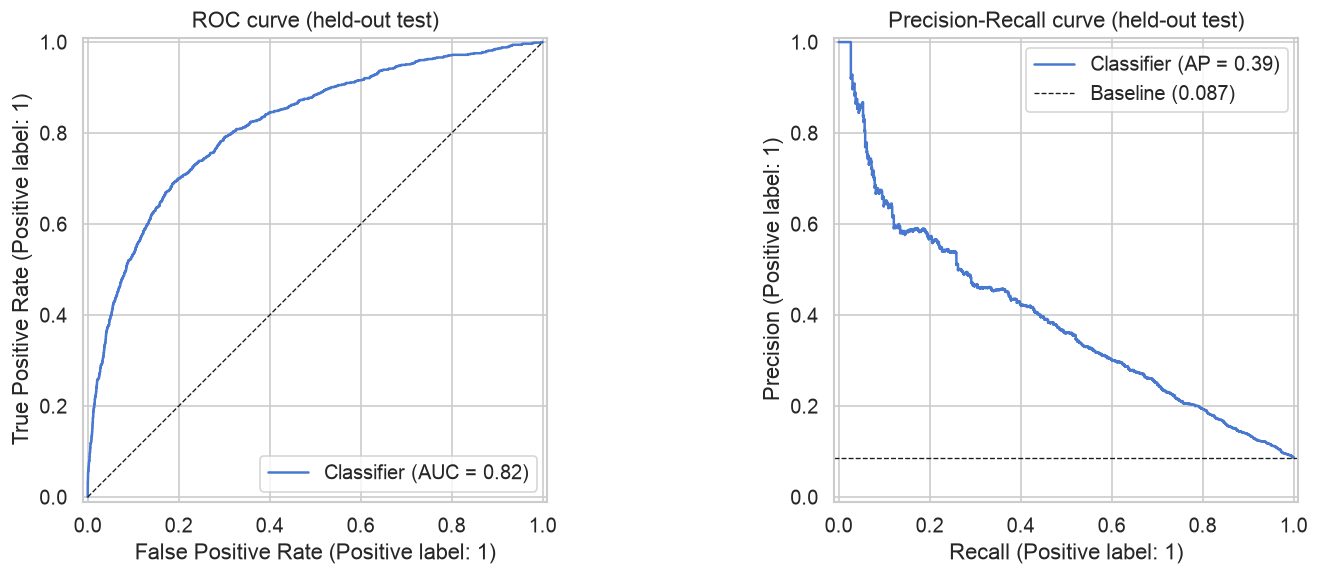

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

RocCurveDisplay.from_predictions(y_test, test_proba, ax=axes[0])
axes[0].plot([0, 1], [0, 1], 'k--', linewidth=0.8)
axes[0].set_title('ROC curve (held-out test)')

PrecisionRecallDisplay.from_predictions(y_test, test_proba, ax=axes[1])
axes[1].axhline(y_test.mean(), color='k', linestyle='--', linewidth=0.8, label=f'Baseline ({y_test.mean():.3f})')
axes[1].legend()
axes[1].set_title('Precision-Recall curve (held-out test)')

plt.tight_layout()
plt.show()

## 5. Calibration

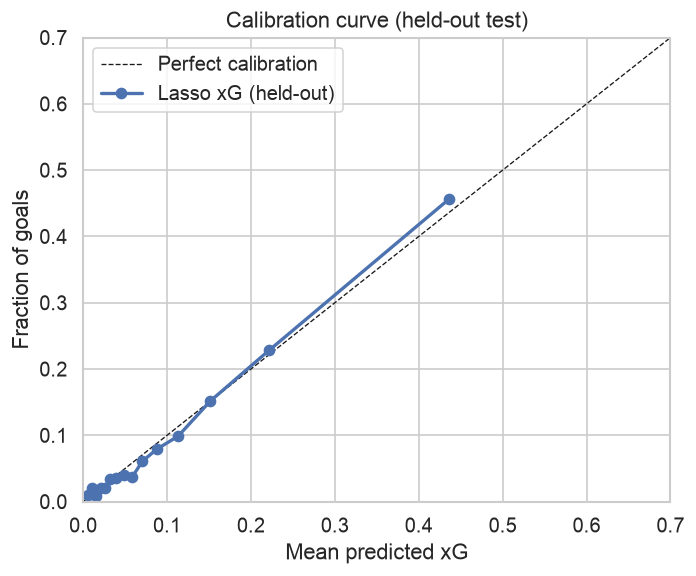

Expected Calibration Error (ECE, held-out test): 0.0082


In [24]:
fraction_pos, mean_pred = calibration_curve(y_test, test_proba, n_bins=15, strategy='quantile')

fig, ax = plt.subplots(figsize=(6, 5))
ax.plot([0, 1], [0, 1], 'k--', linewidth=0.8, label='Perfect calibration')
ax.plot(mean_pred, fraction_pos, 'o-', color='#4C72B0', linewidth=2, markersize=6, label='Lasso xG (held-out)')
ax.set_xlabel('Mean predicted xG')
ax.set_ylabel('Fraction of goals')
ax.set_title('Calibration curve (held-out test)')
ax.legend()
ax.set_xlim(0, 0.7)
ax.set_ylim(0, 0.7)
plt.tight_layout()
plt.show()

bins = np.linspace(0, 1, 11)
bin_ids = np.digitize(test_proba, bins) - 1
ece = sum(
    (np.sum(bin_ids == b) / len(y_test)) * abs(y_test[bin_ids == b].mean() - test_proba[bin_ids == b].mean())
    for b in range(len(bins) - 1) if np.sum(bin_ids == b) > 0
)
print(f"Expected Calibration Error (ECE, held-out test): {ece:.4f}")

## 6. Regularisation Path

As `C` decreases (stronger L1 penalty), features are eliminated one by one until only the most predictive remain. This path shows which features the model considers essential and which are redundant.

Each line is one feature; when it hits zero it has been excluded by Lasso.

In [25]:
C_values = np.logspace(-3, 2, 50)
coef_path = []
n_active_path = []

X_proc = preprocessor.transform(X)

for C in C_values:
    clf = LogisticRegression(
        penalty='l1', C=C, solver='saga',
        max_iter=2000, random_state=42,
    )
    clf.fit(X_proc, y)
    coef_path.append(clf.coef_[0].copy())
    n_active_path.append(np.sum(clf.coef_[0] != 0))

coef_path = np.array(coef_path)   # shape (n_C, n_features)
n_active_path = np.array(n_active_path)

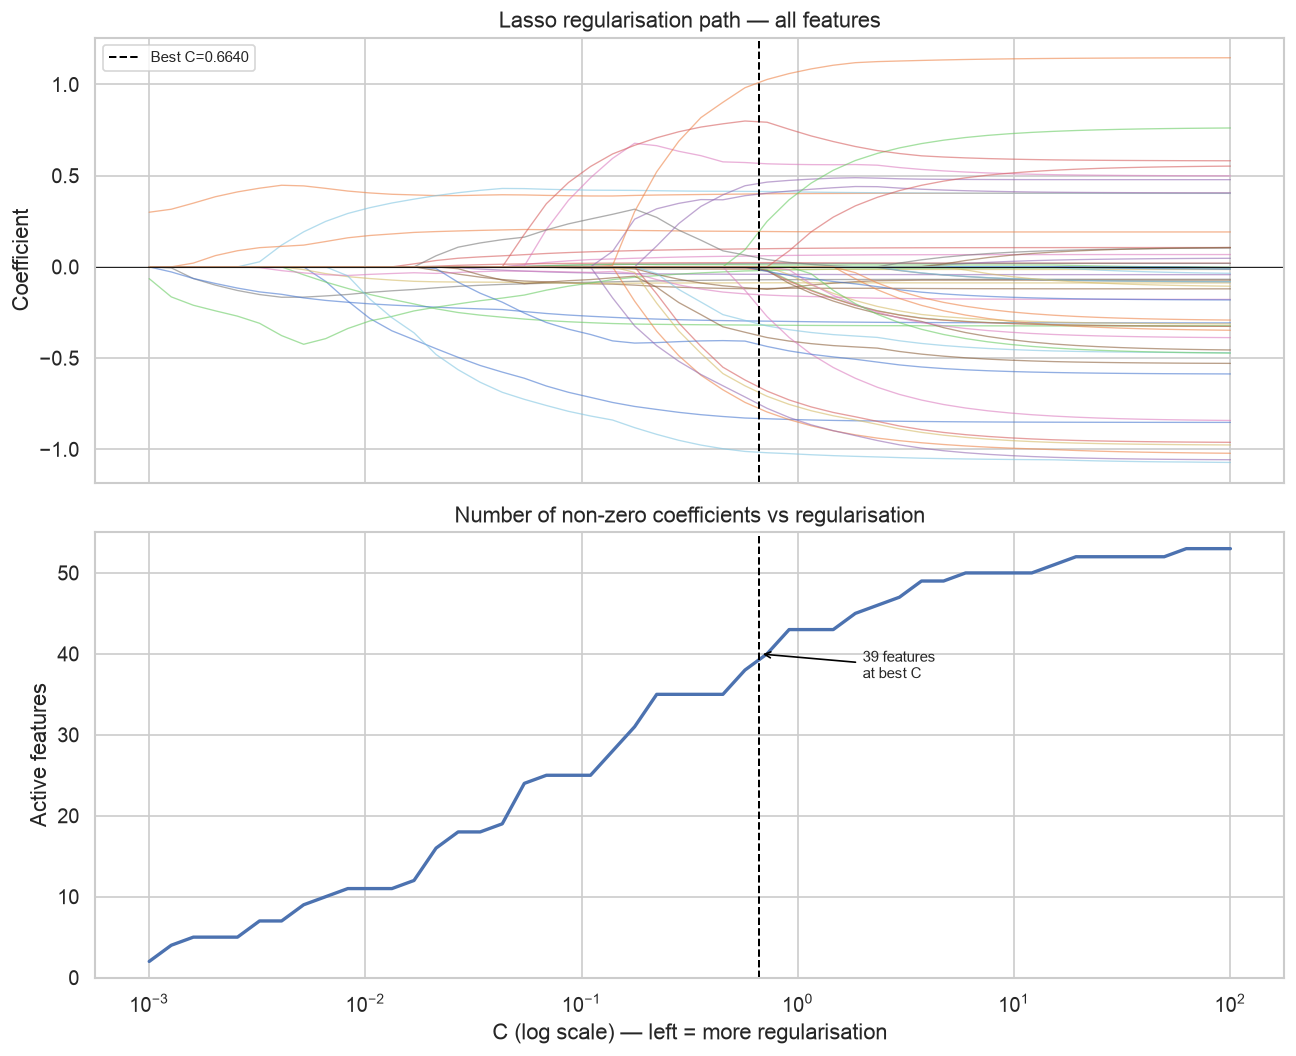

Active features at best C (0.6640): 40 / 54


In [35]:
fig, axes = plt.subplots(2, 1, figsize=(11, 9), sharex=True)

# Top: coefficient paths for every feature
for i in range(coef_path.shape[1]):
    axes[0].semilogx(C_values, coef_path[:, i], linewidth=0.8, alpha=0.6)
axes[0].axvline(best_C, color='black', linewidth=1.2, linestyle='--', label=f'Best C={best_C:.4f}')
axes[0].axhline(0, color='black', linewidth=0.5)
axes[0].set_ylabel('Coefficient')
axes[0].set_title('Lasso regularisation path — all features')
axes[0].legend(fontsize=9)

# Bottom: number of active (non-zero) features
axes[1].semilogx(C_values, n_active_path, color='#4C72B0', linewidth=2)
axes[1].axvline(best_C, color='black', linewidth=1.2, linestyle='--')
axes[1].set_xlabel('C (log scale) — left = more regularisation')
axes[1].set_ylabel('Active features')
axes[1].set_title('Number of non-zero coefficients vs regularisation')
axes[1].set_ylim(0, coef_path.shape[1] + 1)

# Annotate active count at best_C
best_idx = np.argmin(np.abs(C_values - best_C))
n_best = n_active_path[best_idx]
axes[1].annotate(
    '39 features\nat best C',
    xy=(best_C, n_best), xytext=(best_C * 3, n_best - 3),
    arrowprops=dict(arrowstyle='->', color='black'),
    fontsize=9,
)

plt.tight_layout()
plt.show()
print(f"Active features at best C ({best_C:.4f}): {n_best} / {coef_path.shape[1]}")

## 7. Surviving Feature Coefficients

In [27]:
# final_model was already fit on the training-competition shots in the
# evaluation cell above; coefficients reflect that fit.
coefs = pd.Series(
    final_model.named_steps['clf'].coef_[0],
    index=ALL_FEATURE_NAMES,
)

zeroed   = coefs[coefs == 0].index.tolist()
survived = coefs[coefs != 0].sort_values()

print(f"Total features:   {len(coefs)}")
print(f"Non-zero (kept):  {len(survived)}")
print(f"Zeroed out:       {len(zeroed)}")
print(f"\nEliminated features:")
for f in zeroed:
    print(f"  {f}")

Total features:   54
Non-zero (kept):  39
Zeroed out:       15

Eliminated features:
  shot_body_part_Left Foot
  previous_event_type_50/50
  previous_event_type_Bad Behaviour
  previous_event_type_Carry
  previous_event_type_Dispossessed
  previous_event_type_Dribble
  previous_event_type_Dribbled Past
  previous_event_type_Injury Stoppage
  previous_event_type_Interception
  previous_event_type_Pass
  previous_event_type_Player Off
  previous_event_type_Player On
  previous_event_type_Shot
  previous_event_type_Substitution
  previous_event_type_Tactical Shift


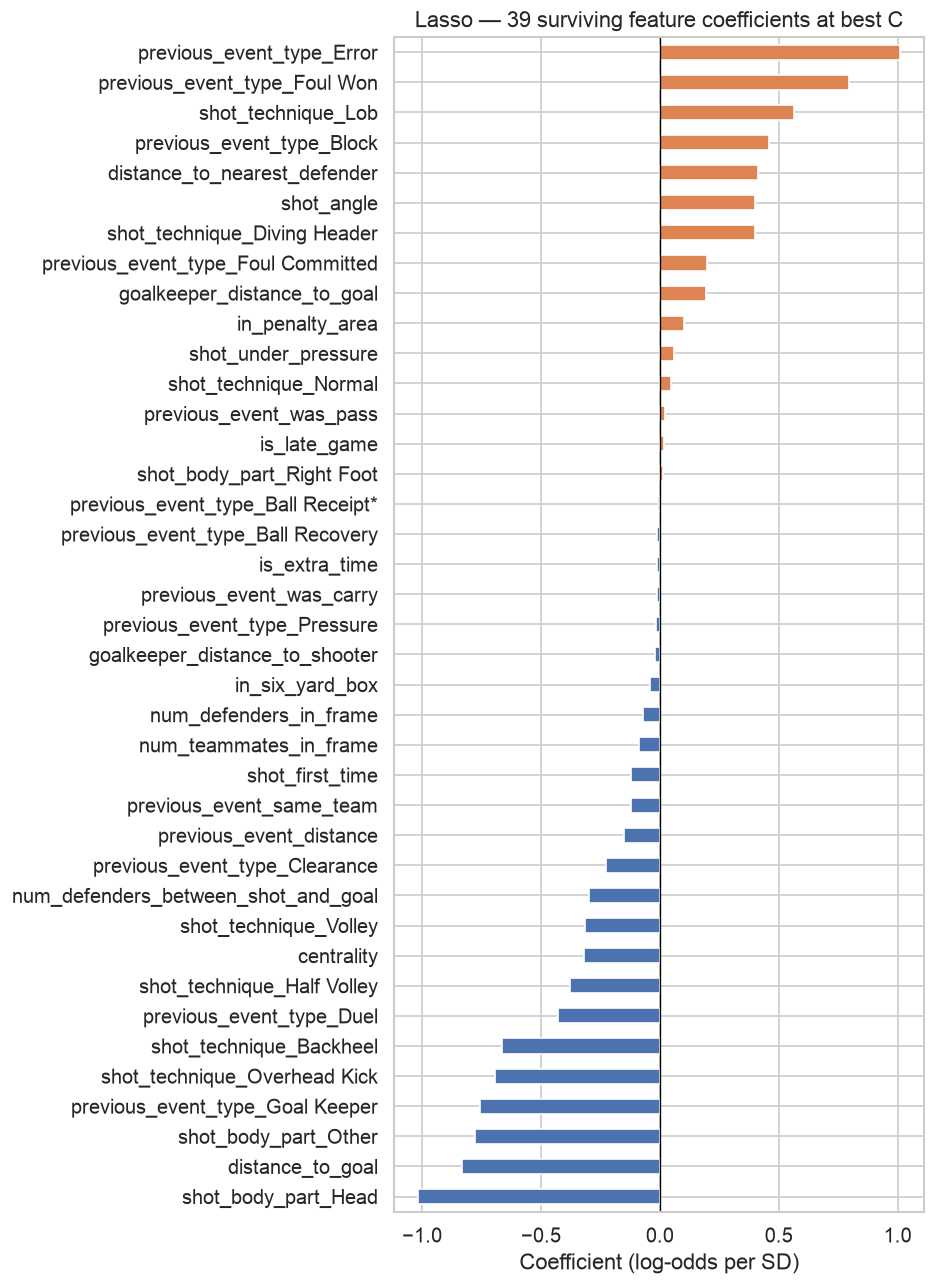

In [28]:
colors = ['#DD8452' if v > 0 else '#4C72B0' for v in survived]

fig, ax = plt.subplots(figsize=(8, max(4, len(survived) * 0.28)))
survived.plot.barh(ax=ax, color=colors, edgecolor='white')
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Coefficient (log-odds per SD)')
ax.set_title(f'Lasso — {len(survived)} surviving feature coefficients at best C')
plt.tight_layout()
plt.show()

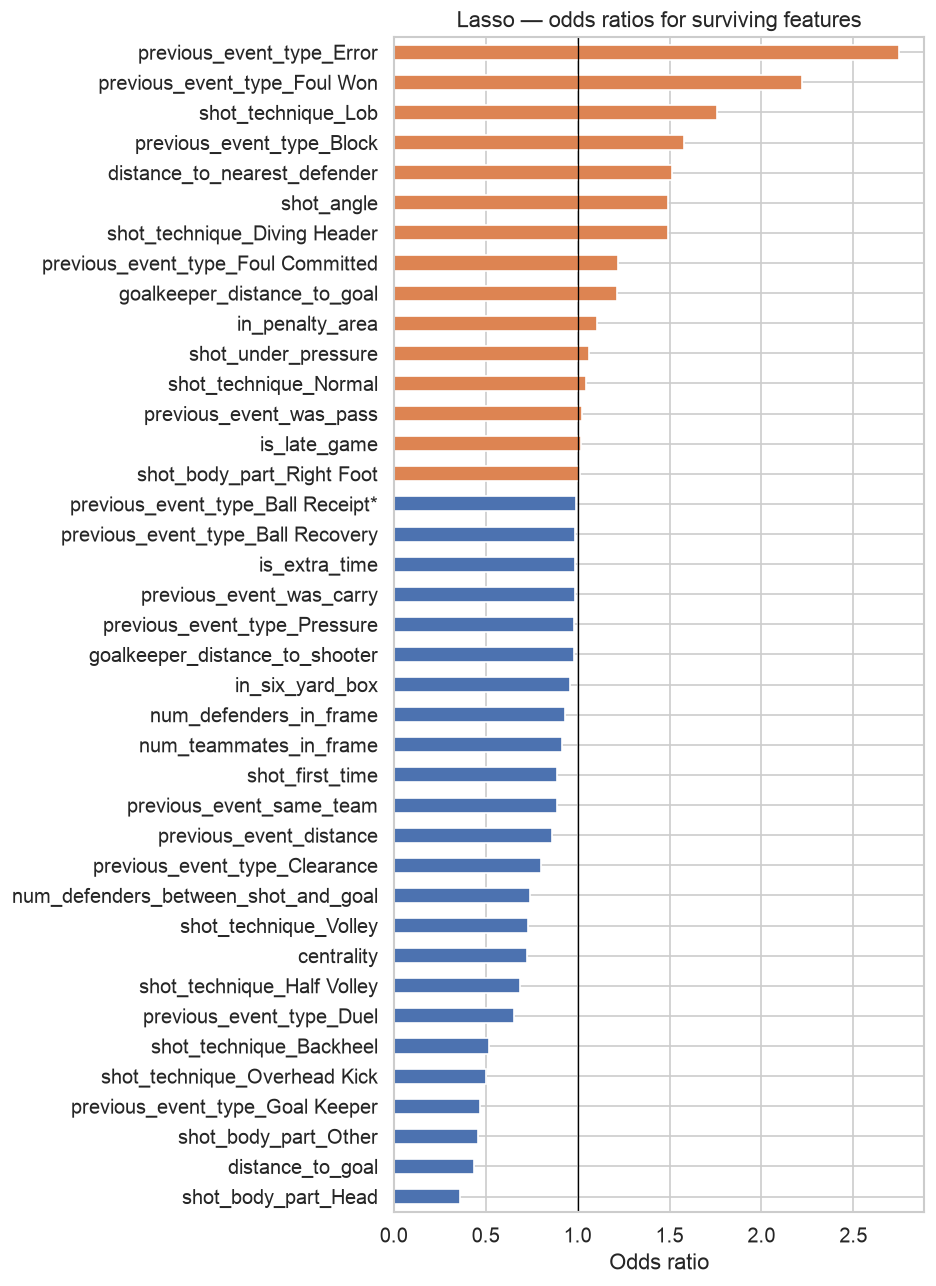

In [29]:
# Odds ratios for surviving features
odds_ratios = np.exp(survived).sort_values()
colors_or = ['#DD8452' if v > 1 else '#4C72B0' for v in odds_ratios]

fig, ax = plt.subplots(figsize=(8, max(4, len(survived) * 0.28)))
odds_ratios.plot.barh(ax=ax, color=colors_or, edgecolor='white')
ax.axvline(1, color='black', linewidth=0.8)
ax.set_xlabel('Odds ratio')
ax.set_title('Lasso — odds ratios for surviving features')
plt.tight_layout()
plt.show()

## 8. Model Comparison

Comparing Lasso against Ridge and a distance-only baseline highlights the trade-off
between sparsity and predictive performance. All three models are fit on the same
training shots and evaluated on the same held-out Serie A 2015/16 test set.

In [33]:
# Distance-only baseline
baseline_model = Pipeline([
    ('pre', Pipeline([
        ('impute', SimpleImputer(strategy='median')),
        ('scale',  StandardScaler()),
    ])),
    ('clf', LogisticRegression(penalty='l2', C=1.0, solver='lbfgs',
                               max_iter=1000, random_state=42)),
])
X_baseline_train = shots_train[['distance_to_goal', 'shot_angle']]
X_baseline_test = shots_test[['distance_to_goal', 'shot_angle']]
baseline_model.fit(X_baseline_train, y)
baseline_test_proba = baseline_model.predict_proba(X_baseline_test)[:, 1]

# Ridge (recomputed here so this notebook is self-contained). Uses Ridge's own
# independently-tuned C from 03_ridge_model.ipynb's Optuna search — NOT
# Lasso's best_C, since C is not comparable across L1 and L2 penalties
# (they shrink coefficients differently, so their optimal regularisation
# strengths aren't expected to match).
RIDGE_BEST_C = 0.20857  # from 03_ridge_model.ipynb's own Optuna search
ridge_model = Pipeline([
    ('pre', preprocessor),
    ('clf', LogisticRegression(penalty='l2', C=RIDGE_BEST_C, solver='lbfgs',
                               max_iter=1000, random_state=42)),
])
ridge_model.fit(X, y)
ridge_test_proba = ridge_model.predict_proba(X_test)[:, 1]

def eval_metrics(y_true, proba):
    return {
        'ROC-AUC':     roc_auc_score(y_true, proba),
        'Log-loss':    log_loss(y_true, proba),
        'Brier score': brier_score_loss(y_true, proba),
    }

comparison = pd.DataFrame({
    'Distance + angle': eval_metrics(y_test, baseline_test_proba),
    'Ridge':            eval_metrics(y_test, ridge_test_proba),
    'Lasso':            metrics,
}).T.round(4)

print("Model comparison (held-out test):")
print(comparison.to_string())

Model comparison (held-out test):
                  ROC-AUC  Log-loss  Brier score
Distance + angle   0.7618    0.2562       0.0712
Ridge              0.8181    0.2329       0.0650
Lasso              0.8180    0.2329       0.0650


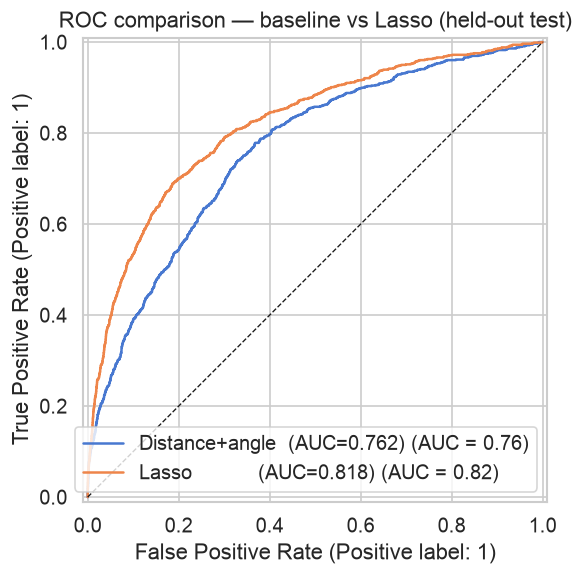

In [36]:
fig, ax = plt.subplots(figsize=(7, 5))

for proba, name, color in [
    (baseline_test_proba, f"Distance+angle  (AUC={eval_metrics(y_test, baseline_test_proba)['ROC-AUC']:.3f})", '#55A868'),
    #(ridge_test_proba,    f"Ridge           (AUC={eval_metrics(y_test, ridge_test_proba)['ROC-AUC']:.3f})",    '#4C72B0'),
    (test_proba,          f"Lasso           (AUC={metrics['ROC-AUC']:.3f})",                                    '#DD8452'),
]:
    RocCurveDisplay.from_predictions(y_test, proba, ax=ax, name=name)

ax.plot([0, 1], [0, 1], 'k--', linewidth=0.8)
ax.set_title('ROC comparison — baseline vs Lasso (held-out test)')
plt.tight_layout()
plt.show()

## 9. Save Model

In [20]:
model_path = '../outputs/lasso_xg_model.pkl'
joblib.dump(final_model, model_path)
print(f"Model saved to {model_path}")

reloaded = joblib.load(model_path)
check = reloaded.predict_proba(X.iloc[:5])[:, 1]
ref   = final_model.predict_proba(X.iloc[:5])[:, 1]
assert np.allclose(check, ref), "Reloaded model predictions differ!"
print("Reload check passed.")

Model saved to ../outputs/lasso_xg_model.pkl
Reload check passed.


## 10. Results Summary

In [32]:
print("="*45)
print(" Lasso Logistic Regression xG Model")
print("="*45)
print(f" Train shots:      {len(shots_train):,} ({train_labels})")
print(f" Test shots:       {len(shots_test):,} ({HOLDOUT_LABEL}, held out)")
print(f" Goal rate:        {y_test.mean():.1%} (held-out test)")
print(f" Total features:   {len(ALL_FEATURE_NAMES)}")
print(f" Best C:           {best_C:.5f}")
print(f" Surviving feats:  {len(survived)} / {len(ALL_FEATURE_NAMES)}")
print(f" CV folds:         5-fold stratified (training set only)")
print("-"*45)
print(" Training CV (OOF) vs held-out test:")
print(comparison_cv_test.to_string())
print("-"*45)
print(" Held-out test — Lasso:")
for name, val in metrics.items():
    print(f" {name:<15} {val:.4f}")
print(f" {'ECE':<15} {ece:.4f}")
print("-"*45)
print(" Held-out test — model comparison:")
print(comparison.to_string())
print("-"*45)
#print(f" Model saved:      {model_path}")
print("="*45)

 Lasso Logistic Regression xG Model
 Train shots:      20,347 (La Liga 2015/16, Champions League 2018/19, Premier League 2015/16, World Cup 2022)
 Test shots:       9,877 (Serie A 2015/16, held out)
 Goal rate:        8.7% (held-out test)
 Total features:   54
 Best C:           0.66397
 Surviving feats:  39 / 54
 CV folds:         5-fold stratified (training set only)
---------------------------------------------
 Training CV (OOF) vs held-out test:
             Training CV (OOF)  Held-out test (Serie A 2015/16)
ROC-AUC                 0.8038                           0.8180
Log-loss                0.2606                           0.2329
Brier score             0.0743                           0.0650
---------------------------------------------
 Held-out test — Lasso:
 ROC-AUC         0.8180
 Log-loss        0.2329
 Brier score     0.0650
 ECE             0.0082
---------------------------------------------
 Held-out test — model comparison:
                  ROC-AUC  Log-loss  Brier